In [1]:
# To install the repo, run (potentially pwd() needs to be adjusted)
#!pip install -e .

In [2]:
import LACT
from LACT import *

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from lammps import lammps, LMP_STYLE_ATOM, LMP_TYPE_VECTOR, LMP_TYPE_ARRAY
from ctypes import c_double, c_int

import scipy
from scipy import optimize

In [4]:
lmp_initialise = '''
# ------------------------ INITIALIZATION ----------------------------
processors    * * *
units         metal
dimension    3
boundary    p    p    p
atom_style   atomic
atom_modify map yes


box        tilt large
#--------------------------- LAMMPS Data File--------------------------
#read_data    input_data/thicker_domain.lmp
read_data    input_data/4b_step.lmp
change_box    all triclinic
reset_atom_ids sort yes

#--------------
pair_style    eam/alloy
pair_coeff    * * input_data/Cu_mishin1.eam.alloy Cu

#-------------------Various continuation commands----------------------
compute forces all property/atom fx fy fz
compute ids all property/atom id
compute x_check all property/atom x y z
#atom_modify map yes
'''

In [5]:
lmp = lammps(cmdargs=['-screen', 'none'])

lmp.commands_string(lmp_initialise)

In [6]:
def change_box_command(limits,direction="x"):
    command = f"""
     change_box all {direction} final {limits[0]} {limits[1]} units box
    """
    return command

def update_command_box_x(x,box_size):
    direction = "x"
    i = 0 if direction=="x" else 1 if direction=="y" else 2
    return change_box_command([box_size[0][i]+x,box_size[1][i]-x],direction=direction)

In [7]:
system = atom_cont_system(lmp,update_command_box_x)

In [8]:
system.data["Y_s"]

[]

In [9]:
system.quasi_static_run(0.0, 0.1, 2, verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A quasi-static run: adjust μ and minimise in LAMMPS
        
Iteration step:  1   , Solution step:  1   , Continuation parameter:  0.0
Iteration step:  2   , Solution step:  2   , Continuation parameter:  0.1


In [10]:
ds_default = 1e-0
ds_smallest = 1e-3
ds_largest = 2e0

system.continuation_run(25,
                     ds_default = ds_default,
                     ds_smallest = ds_smallest,
                     ds_largest = ds_largest,
                     verbose=True)


        %%%%%%%%%%%%%%%%%%%%%%%%%%%
        A continuation run: solve extended system to find points on the solution path.
        


/home/mb/.local/lib/python3.11/site-packages/scipy/optimize/_nonlin.py:367: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


0:  |F(x)| = 3.18511e-07; step 1
Iteration step:  1   , Solution step:  3   , Continuation parameter:  0.1240412460940661
0:  |F(x)| = 4.43701e-07; step 1
Iteration step:  2   , Solution step:  4   , Continuation parameter:  0.14809436762644393
0:  |F(x)| = 3.69808e-07; step 1
Iteration step:  3   , Solution step:  5   , Continuation parameter:  0.1721495443638592
0:  |F(x)| = 3.14576e-07; step 1
Iteration step:  4   , Solution step:  6   , Continuation parameter:  0.19620724713588217
0:  |F(x)| = 4.82859e-07; step 1
Iteration step:  5   , Solution step:  7   , Continuation parameter:  0.22026991111762143
0:  |F(x)| = 3.34288e-07; step 1
ds doubled, now equal to  2.0 .
Iteration step:  6   , Solution step:  8   , Continuation parameter:  0.24433591046679978
0:  |F(x)| = 6.48376e-07; step 1
Iteration step:  7   , Solution step:  9   , Continuation parameter:  0.29247207064220726
0:  |F(x)| = 1.33801e-06; step 1
Iteration step:  8   , Solution step:  10   , Continuation parameter:  0.340

In [11]:
path = 'dumps/thin_domain/interface_tests/'
file_name = 'dump'

In [12]:
system.dump_data(path,file_name)

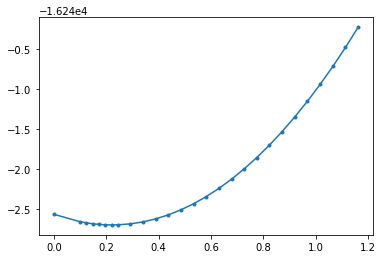

In [13]:
system.compute_energies()
μs = [Y[-1] for Y in system.data["Y_s"]]
plt.plot(μs,system.data["energies"],'.-')